# Notebook 1 — Exploratory Data Analysis & Feature Engineering
## Датасет: Sparkov Credit Card Fraud Detection

**Цель ноутбука:**  
Провести осмысленный разведочный анализ датасета, сконструировать информативные признаки
и отобрать финальный набор для обучения baseline ML-моделей в Notebook 2.

**Структура:**
1. Импорты и загрузка данных
2. Первичный осмотр — типы, пропуски, дубли, дисбаланс классов
3. Анализ сырых признаков — что дропаем сразу и почему
4. Feature Engineering — конструирование новых признаков
5. Анализ связи признаков с таргетом (корреляции + Mutual Information)
6. Финальный отбор признаков с обоснованием
7. Сохранение обработанных данных для Notebook 2

**Важное методологическое ограничение:**  
Все статистики (средние, частоты, fraud rate по категориям и т.д.) вычисляются
**только на train** и затем применяются к test, чтобы исключить утечку данных.
Временное разбиение train (2019) / test (2020) воспроизводит реальные условия эксплуатации.

## 1. Импорты и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Пути 
RAW       = Path("../data/raw")
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

# Стиль графиков
plt.rcParams["figure.dpi"]   = 120
plt.rcParams["font.family"]  = "DejaVu Sans"
sns.set_style("whitegrid")
PALETTE = {"legit": "#2563EB", "fraud": "#DC2626"}

# Загрузка
train = pd.read_csv(RAW / "fraudTrain.csv", index_col=0)
test  = pd.read_csv(RAW / "fraudTest.csv",  index_col=0)

print(f"Train: {train.shape[0]:,} строк, {train.shape[1]} колонок")
print(f"Test:  {test.shape[0]:,} строк, {test.shape[1]} колонок")
print(f"\nДоля фрода в train: {train['is_fraud'].mean():.4%}")
print(f"Доля фрода в test:  {test['is_fraud'].mean():.4%}")

Train: 1,296,675 строк, 22 колонок
Test:  555,719 строк, 22 колонок

Доля фрода в train: 0.5789%
Доля фрода в test:  0.3860%


In [2]:
train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

## 2. Первичный осмотр датасета

Смотрим на:
- типы данных и их соответствие смыслу колонки
- наличие пропусков и дублей
- дисбаланс целевой переменной
- диапазоны числовых значений

Уже на этом этапе часть колонок можно исключить **без анализа** — по логике предметной области:
- `trans_num` — уникальный хэш транзакции, нет предсказательной силы
- `cc_num` — номер карты: слишком высокая кардинальность, риск переобучения;  
  поведение держателя мы закодируем через агрегаты
- `first`, `last`, `zip` — PII (Personally Identifiable Information), не несут обобщаемого сигнала
- `dob` — дата рождения: нужна только для расчёта возраста, после чего дропается
- `unix_time` — дублирует `trans_date_trans_time` в другом формате
- `merch_lat` / `merch_long` + `lat` / `long` — сырые координаты заменим  
  на расстояние home→merchant; сами координаты после этого не нужны

In [4]:
# Типы и пропуски
info = pd.DataFrame({
    "dtype":    train.dtypes,
    "n_unique": train.nunique(),
    "null_%":   (train.isnull().mean() * 100).round(2),
    "sample":   train.iloc[0],
})
info

,dtype,n_unique,null_%,sample
trans_date_trans_time,object,1274791,0.0,2019-01-01 00:00:18
cc_num,int64,983,0.0,2703186189652095
merchant,object,693,0.0,"fraud_Rippin, Kub and Mann"
category,object,14,0.0,misc_net
amt,float64,52928,0.0,4.97
first,object,352,0.0,Jennifer
last,object,481,0.0,Banks
gender,object,2,0.0,F
street,object,983,0.0,561 Perry Cove
city,object,894,0.0,Moravian Falls


In [5]:
# Дубли
n_dup = train.duplicated().sum()
print(f"\nПолных дублей в train: {n_dup}")


Полных дублей в train: 0


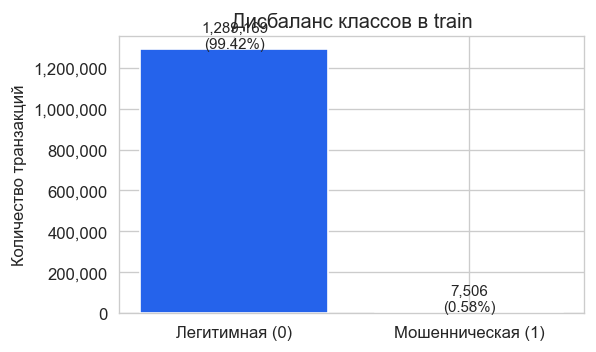

In [6]:
# Дисбаланс классов
fig, ax = plt.subplots(figsize=(5, 3))
counts = train["is_fraud"].value_counts()
ax.bar(["Легитимная (0)", "Мошенническая (1)"],
       counts.values,
       color=[PALETTE["legit"], PALETTE["fraud"]])
for i, v in enumerate(counts.values):
    ax.text(i, v + 5000, f"{v:,}\n({v/len(train):.2%})",
            ha="center", fontsize=9)
ax.set_title("Дисбаланс классов в train")
ax.set_ylabel("Количество транзакций")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.show()

In [7]:
# Диапазоны числовых фичей
train.describe().T

,count,mean,std,min,25%,50%,75%,max
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01
is_fraud,1296675.0,5.788652e-03,7.586269e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


## 3. Удаление нерелевантных признаков

Колонки, которые удаляем немедленно и безвозвратно:

| Колонка | Причина удаления |
|---|---|
| `trans_num` | Уникальный ID транзакции — нет сигнала |
| `cc_num` | Слишком высокая кардинальность; поведение карты закодируем через агрегаты |
| `first`, `last`, `zip` | PII без обобщаемого паттерна |
| `unix_time` | Дублирует `trans_date_trans_time` |
| `merch_lat`, `merch_long`, `lat`, `long` | Заменяем на расстояние home→merchant |

Колонки `dob` и `trans_date_trans_time` пока **оставляем** — они нужны  
для конструирования новых признаков на следующем шаге.

In [8]:
DROP_IMMEDIATELY = ["trans_num", "cc_num", "first", "last", "zip", "unix_time"]

train = train.drop(columns=DROP_IMMEDIATELY)
test  = test.drop(columns=DROP_IMMEDIATELY)

print(f"После дропа: train {train.shape}, test {test.shape}")
print(f"Оставшиеся колонки:\n{list(train.columns)}")

После дропа: train (1296675, 16), test (555719, 16)
Оставшиеся колонки:
['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'street', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat', 'merch_long', 'is_fraud']


## 4. Feature Engineering

Конструируем новые признаки в несколько групп:

### 4.1 Временны́е признаки
Из `trans_date_trans_time` извлекаем:
- `hour` — час транзакции (фрод может концентрироваться ночью)
- `day_of_week` — день недели (0=пн … 6=вс)
- `month` — месяц
- `is_night` — флаг ночного времени (22:00–05:00)
- `is_weekend` — флаг выходного дня

### 4.2 Возраст держателя карты
Из `dob` и даты транзакции считаем `age_at_txn`.  
После расчёта `dob` дропается.

### 4.3 Географическое расстояние
Так как Земля имеет около сферическую форму, используем расстояние по формуле
Хаверсина между домашним адресом держателя и местоположением мерчанта
(евклидово расстояние дало бы огромную погрешность из-за кривизны поверхности).  
После расчёта сырые координаты дропаются.

### 4.4 Поведенческие агрегаты держателя карты
Считаем **только по train**, потом map-ируем на test:
- `user_mean_amt` — средняя сумма транзакций держателя
- `user_std_amt` — стандартное отклонение суммы
- `user_txn_count` — число транзакций в train
- `amt_zscore` — z-score суммы транзакции относительно профиля держателя:
  насколько данная транзакция отклоняется от личного профиля в единицах
  стандартного отклонения

### 4.5 Агрегаты по категории мерчанта
- `cat_mean_amt` — средняя сумма по категории
- `cat_fraud_rate` — исторический fraud rate категории  
  (**только по train** — иначе утечка на test!)

### 4.6 Кодирование категориальных признаков
- `gender` - бинарный флаг (M=1, F=0)
- `category` - OHE (14 уникальных значений; Label Encoding создаст искусственный
  порядок между категориями, которого нет по смыслу)
- `merchant`, `job`, `city`, `state` - Target Encoding с K-Fold и сглаживанием:
  высокая кардинальность делает OHE неприменимым, а Target Encoding заменяет
  каждую категорию её историческим fraud rate, посчитанным без утечки данных

**Защита от утечки в Target Encoding:**  
На train используем K-Fold (каждая строка кодируется статистиками,
посчитанными без её участия). На test — маппинг по статистикам всего train.  
Редкие категории сглаживаются к глобальному среднему через параметр `m`.

In [9]:
for df in [train, test]:
    dt = pd.to_datetime(df["trans_date_trans_time"])
    df["hour"]        = dt.dt.hour
    df["day_of_week"] = dt.dt.dayofweek   # 0=пн, 6=вс
    df["month"]       = dt.dt.month
    df["is_night"]    = ((dt.dt.hour >= 22) | (dt.dt.hour <= 5)).astype(int)
    df["is_weekend"]  = (dt.dt.dayofweek >= 5).astype(int)

    # Возраст на момент транзакции
    dob_dt = pd.to_datetime(df["dob"])
    df["age_at_txn"] = ((dt - dob_dt).dt.days / 365.25).astype(int)

# Исходники больше не нужны
train.drop(columns=["trans_date_trans_time", "dob"], inplace=True)
test.drop(columns=["trans_date_trans_time",  "dob"], inplace=True)

print("Временные признаки и возраст добавлены")
train[["hour", "day_of_week", "month", "is_night", "is_weekend", "age_at_txn"]].head(3)

Временные признаки и возраст добавлены


,hour,day_of_week,month,is_night,is_weekend,age_at_txn
0,0,1,1,1,0,30
1,0,1,1,1,0,40
2,0,1,1,1,0,56


In [10]:
def haversine_km(lat1: np.ndarray, lon1: np.ndarray,
                 lat2: np.ndarray, lon2: np.ndarray) -> np.ndarray:
    """
    Векторизованная формула Хаверсина.
    Возвращает расстояние в км между двумя точками на поверхности Земли.
    """
    R = 6371.0
    phi1, phi2  = np.radians(lat1), np.radians(lat2)
    dphi        = np.radians(lat2 - lat1)
    dlambda     = np.radians(lon2 - lon1)
    a = (np.sin(dphi / 2) ** 2
         + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))


for df in [train, test]:
    df["home_merch_dist_km"] = haversine_km(
        df["lat"].values,      df["long"].values,
        df["merch_lat"].values, df["merch_long"].values
    )

# Координаты больше не нужны — всё расстояние закодировано в одном признаке
train.drop(columns=["lat", "long", "merch_lat", "merch_long"], inplace=True)
test.drop(columns=["lat",  "long", "merch_lat", "merch_long"], inplace=True)

print(f"home_merch_dist_km | train: "
      f"min={train['home_merch_dist_km'].min():.1f} км  "
      f"median={train['home_merch_dist_km'].median():.1f} км  "
      f"max={train['home_merch_dist_km'].max():.1f} км")

home_merch_dist_km | train: min=0.0 км  median=78.2 км  max=152.1 км


In [11]:
# Агрегаты считаются ТОЛЬКО по train — потом маппируются на test
# street однозначно идентифицирует держателя карты в этом датасете
# (983 уникальных street = 983 уникальных держателя)

user_stats = (
    train.groupby("street")["amt"]
    .agg(
        user_mean_amt  = "mean",
        user_std_amt   = "std",
        user_txn_count = "count",
    )
    .reset_index()
)

global_mean_amt = train["amt"].mean()

train = train.merge(user_stats, on="street", how="left")
test  = test.merge(user_stats,  on="street", how="left")

test["user_mean_amt"]  = test["user_mean_amt"].fillna(global_mean_amt)
test["user_std_amt"]   = test["user_std_amt"].fillna(train["user_std_amt"].mean())
test["user_txn_count"] = test["user_txn_count"].fillna(0)

for df in [train, test]:
    df["amt_zscore"] = (
        (df["amt"] - df["user_mean_amt"])
        / df["user_std_amt"].replace(0, 1)
    )

# street дропаем — его сигнал уже в агрегатах
train.drop(columns=["street"], inplace=True)
test.drop(columns=["street"],  inplace=True)

print("Поведенческие агрегаты добавлены")
train[["user_mean_amt", "user_std_amt",
             "user_txn_count", "amt_zscore"]].describe().round(3)

Поведенческие агрегаты добавлены


,user_mean_amt,user_std_amt,user_txn_count,amt_zscore
count,1296675.000,1296675.000,1296675.000,1296675.000
mean,70.351,141.346,1818.725,-0.000
std,19.410,73.303,742.506,1.000
min,42.952,60.247,7.000,-2.825
25%,59.814,103.591,1466.000,-0.395
50%,65.094,122.378,2000.000,-0.179
75%,83.278,149.717,2524.000,0.094
max,948.818,1202.988,3123.000,52.890


In [12]:
global_fraud_rate = train["is_fraud"].mean()

cat_stats = (
    train.groupby("category")
    .agg(
        cat_mean_amt   = ("amt",      "mean"),
        cat_fraud_rate = ("is_fraud", "mean"),
    )
    .reset_index()
)

train = train.merge(cat_stats, on="category", how="left")
test  = test.merge(cat_stats,  on="category", how="left")

test["cat_mean_amt"]   = test["cat_mean_amt"].fillna(train["amt"].mean())
test["cat_fraud_rate"] = test["cat_fraud_rate"].fillna(global_fraud_rate)

print("Агрегаты по категории добавлены")
cat_stats.sort_values("cat_fraud_rate", ascending=False).round(4)

Агрегаты по категории добавлены


,category,cat_mean_amt,cat_fraud_rate
11,shopping_net,88.4241,0.0176
8,misc_net,80.8651,0.0145
4,grocery_pos,116.9610,0.0141
12,shopping_pos,79.7792,0.0072
2,gas_transport,63.4346,0.0047
9,misc_pos,62.8910,0.0031
3,grocery_net,53.6701,0.0029
13,travel,111.5047,0.0029
0,entertainment,64.2104,0.0025
10,personal_care,47.9677,0.0024


In [13]:
# gender - бинарный флаг
for df in [train, test]:
    df["gender_male"] = (df["gender"] == "M").astype(int)
    df.drop(columns=["gender"], inplace=True)

# category - OHE
ohe_train = pd.get_dummies(train["category"], prefix="cat", dtype=int)
ohe_test  = pd.get_dummies(test["category"],  prefix="cat", dtype=int)

# Выравниваем test по колонкам train
ohe_test = ohe_test.reindex(columns=ohe_train.columns, fill_value=0)

train = pd.concat([train.drop(columns=["category"]), ohe_train], axis=1)
test  = pd.concat([test.drop(columns=["category"]),  ohe_test],  axis=1)

print(f"OHE добавил {ohe_train.shape[1]} столбцов для category:")
print(list(ohe_train.columns))

OHE добавил 14 столбцов для category:
['cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']


In [14]:
from sklearn.model_selection import KFold
import json

def kfold_target_encode_train(
    df: pd.DataFrame,
    col: str,
    target: str,
    n_splits: int = 5,
    m: float = 20.0,
    random_state: int = 42,
) -> pd.Series:
    """
    K-Fold Target Encoding для train.
    Каждая строка кодируется fraud rate по остальным фолдам —
    без участия самой строки. Исключает утечку целевой переменной.
    Параметр m сглаживает редкие категории к глобальному среднему.
    """
    global_mean = df[target].mean()
    encoded     = pd.Series(np.nan, index=df.index)
    kf          = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(df):
        fold_train = df.iloc[train_idx]
        agg        = fold_train.groupby(col)[target].agg(["mean", "count"])
        mapping    = (
            (agg["count"] * agg["mean"] + m * global_mean)
            / (agg["count"] + m)
        )
        encoded.iloc[val_idx] = df.iloc[val_idx][col].map(mapping)

    encoded.fillna(global_mean, inplace=True)
    return encoded


def target_encode_test(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    col: str,
    target: str,
    m: float = 20.0,
) -> pd.Series:
    """
    Target Encoding для test.
    Маппинг строится по всему train — новые категории получают global_mean.
    """
    global_mean = train_df[target].mean()
    agg         = train_df.groupby(col)[target].agg(["mean", "count"])
    mapping     = (
        (agg["count"] * agg["mean"] + m * global_mean)
        / (agg["count"] + m)
    )
    return test_df[col].map(mapping).fillna(global_mean)


HIGH_CARD_COLS = ["merchant", "job", "city", "state"]
M_SMOOTHING    = 20
te_maps        = {}

for col in HIGH_CARD_COLS:
    new_col = f"{col}_te"
    print(f"  Encoding '{col}' ({train[col].nunique()} уникальных) - '{new_col}'")

    train[new_col] = kfold_target_encode_train(
        train, col=col, target="is_fraud", m=M_SMOOTHING
    )
    test[new_col] = target_encode_test(
        train, test, col=col, target="is_fraud", m=M_SMOOTHING
    )

    # Маппинг по всему train — для инференса в Notebook 2
    agg = train.groupby(col)["is_fraud"].agg(["mean", "count"])
    te_maps[col] = (
        (agg["count"] * agg["mean"] + M_SMOOTHING * global_fraud_rate)
        / (agg["count"] + M_SMOOTHING)
    ).to_dict()

    train.drop(columns=[col], inplace=True)
    test.drop(columns=[col],  inplace=True)

print(f"\nTarget Encoding завершён")
print(f"Признаков итого: {len([c for c in train.columns if c != 'is_fraud'])}")

# Сохраняем маппинги для воспроизводимости
te_maps_path = PROCESSED / "target_encoding_maps.json"
with open(te_maps_path, "w", encoding="utf-8") as f:
    json.dump(te_maps, f, ensure_ascii=False, indent=2)
print(f"Маппинги сохранены: {te_maps_path}")

  Encoding 'merchant' (693 уникальных) - 'merchant_te'
  Encoding 'job' (494 уникальных) - 'job_te'
  Encoding 'city' (894 уникальных) - 'city_te'
  Encoding 'state' (51 уникальных) - 'state_te'

Target Encoding завершён
Признаков итого: 34
Маппинги сохранены: ../data/processed/target_encoding_maps.json


In [15]:
feature_cols = [c for c in train.columns if c != "is_fraud"]

print(f"Итоговых признаков: {len(feature_cols)}\n")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

Итоговых признаков: 34

   1. amt
   2. city_pop
   3. hour
   4. day_of_week
   5. month
   6. is_night
   7. is_weekend
   8. age_at_txn
   9. home_merch_dist_km
  10. user_mean_amt
  11. user_std_amt
  12. user_txn_count
  13. amt_zscore
  14. cat_mean_amt
  15. cat_fraud_rate
  16. gender_male
  17. cat_entertainment
  18. cat_food_dining
  19. cat_gas_transport
  20. cat_grocery_net
  21. cat_grocery_pos
  22. cat_health_fitness
  23. cat_home
  24. cat_kids_pets
  25. cat_misc_net
  26. cat_misc_pos
  27. cat_personal_care
  28. cat_shopping_net
  29. cat_shopping_pos
  30. cat_travel
  31. merchant_te
  32. job_te
  33. city_te
  34. state_te


## 5. Анализ связи признаков с таргетом

Используем два метода:

**Корреляция Спирмена** — устойчива к выбросам и нелинейным монотонным связям,
подходит лучше Пирсона для смешанных данных с сильным дисбалансом классов.

**Mutual Information (MI)** — захватывает любые нелинейные зависимости,
не предполагает нормальности распределения. Особенно ценен тем, что улавливает
связи которые корреляция пропускает.

Используем оба метода совместно: признак считается слабым только если он
показывает низкий сигнал по **обоим** критериям одновременно.

### Корреляция Спирмена

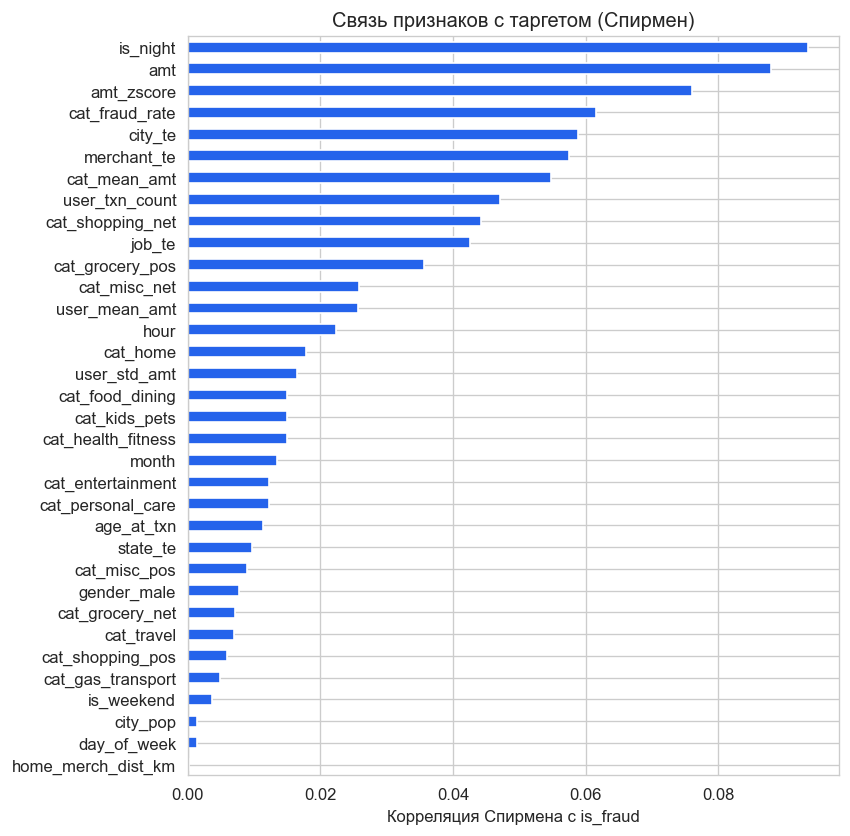

In [17]:
spearman_corr = (
    train[feature_cols + ["is_fraud"]]
    .corr(method="spearman")["is_fraud"]
    .drop("is_fraud")
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 8))
spearman_corr.plot.barh(ax=ax, color=PALETTE["legit"], edgecolor="white")
ax.set_xlabel("Корреляция Спирмена с is_fraud")
ax.set_title("Связь признаков с таргетом (Спирмен)")
ax.invert_yaxis()
plt.show()

### Mutual Information

Корреляция Спирмена измеряет только монотонные связи — если признак влияет
на таргет нелинейно (например, фрод концентрируется в определённом диапазоне
часов, но не монотонно растёт), корреляция это не уловит.

Mutual Information не делает никаких предположений о форме зависимости
и является более универсальным инструментом отбора признаков.

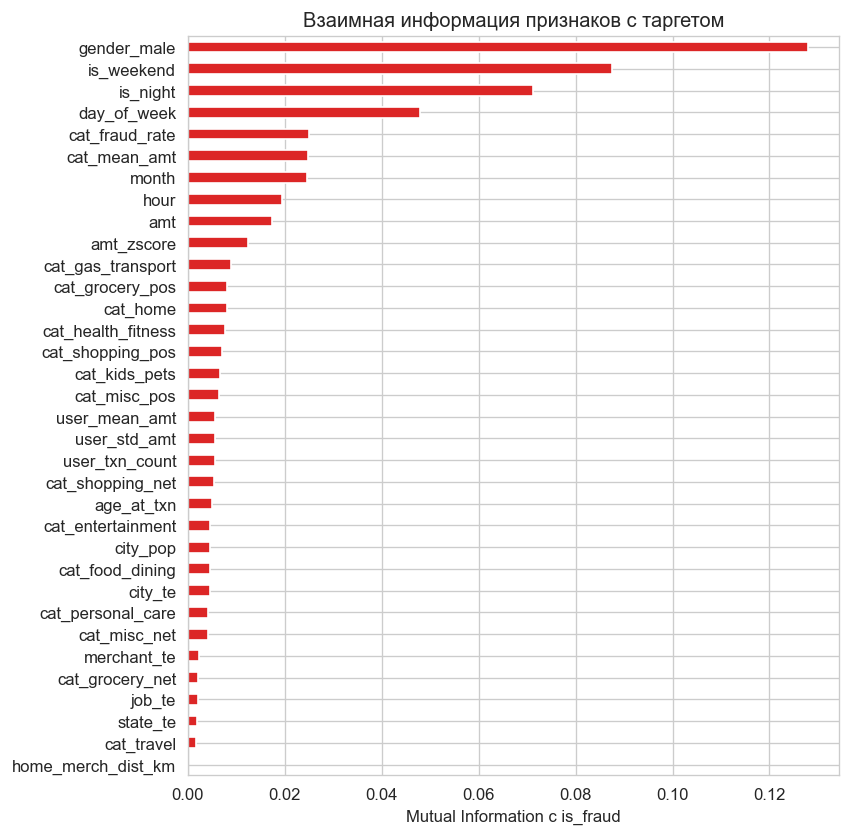

In [18]:
X_mi = train[feature_cols].fillna(0)
y_mi = train["is_fraud"]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 8))
mi_series.plot.barh(ax=ax, color=PALETTE["fraud"], edgecolor="white")
ax.set_xlabel("Mutual Information с is_fraud")
ax.set_title("Взаимная информация признаков с таргетом")
ax.invert_yaxis()
plt.show()

### Сводный рейтинг

Объединяем оба метода в единый `combined score`:
- вес Спирмена — 40%
- вес MI — 60% (приоритет MI как более универсального метода)

Оба показателя нормируются к [0, 1] перед объединением.

In [19]:
importance_df = pd.DataFrame({
    "spearman": spearman_corr,
    "mi":       mi_series,
}).sort_values("mi", ascending=False)

importance_df["spearman_norm"] = importance_df["spearman"] / importance_df["spearman"].max()
importance_df["mi_norm"]       = importance_df["mi"]       / importance_df["mi"].max()
importance_df["combined"]      = (
    0.4 * importance_df["spearman_norm"] +
    0.6 * importance_df["mi_norm"]
)
importance_df = importance_df.sort_values("combined", ascending=False)

print("Сводный рейтинг признаков")
importance_df[["spearman", "mi", "combined"]].round(4)

Сводный рейтинг признаков


,spearman,mi,combined
is_night,0.0935,0.0713,0.7343
gender_male,0.0076,0.1279,0.6327
amt,0.0879,0.0174,0.4574
is_weekend,0.0036,0.0875,0.4258
amt_zscore,0.0760,0.0124,0.3831
cat_fraud_rate,0.0615,0.0249,0.3799
cat_mean_amt,0.0547,0.0248,0.3501
city_te,0.0589,0.0045,0.2729
merchant_te,0.0574,0.0023,0.2562
day_of_week,0.0013,0.0478,0.2297


## 6. Финальный отбор признаков

На основе сводного рейтинга принимаем следующие решения:

**Дропаем:**
- `home_merch_dist_km` — combined score = 0.001, практически нулевой сигнал.
  Подтверждает гипотезу: в синтетическом датасете мошеннические транзакции
  генерировались без географической аномалии
- `city_pop` — combined score = 0.027, сигнал слабее большинства OHE-категорий

**Оставляем все остальные признаки**, включая слабые OHE-столбцы категорий:
они работают совместно как группа и tree-based модели умеют
использовать их в комбинации. Дропать отдельные OHE-столбцы нецелесообразно.

**Итого:** 32 признака для Notebook 2.

In [20]:
DROP_WEAK = ["home_merch_dist_km", "city_pop"]

train.drop(columns=DROP_WEAK, inplace=True)
test.drop(columns=DROP_WEAK,  inplace=True)

feature_cols = [c for c in train.columns if c != "is_fraud"]

print(f"Финальных признаков: {len(feature_cols)}")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

Финальных признаков: 32
   1. amt
   2. hour
   3. day_of_week
   4. month
   5. is_night
   6. is_weekend
   7. age_at_txn
   8. user_mean_amt
   9. user_std_amt
  10. user_txn_count
  11. amt_zscore
  12. cat_mean_amt
  13. cat_fraud_rate
  14. gender_male
  15. cat_entertainment
  16. cat_food_dining
  17. cat_gas_transport
  18. cat_grocery_net
  19. cat_grocery_pos
  20. cat_health_fitness
  21. cat_home
  22. cat_kids_pets
  23. cat_misc_net
  24. cat_misc_pos
  25. cat_personal_care
  26. cat_shopping_net
  27. cat_shopping_pos
  28. cat_travel
  29. merchant_te
  30. job_te
  31. city_te
  32. state_te


In [22]:
cols_to_save = feature_cols + ["is_fraud"]

train[cols_to_save].to_csv(PROCESSED / "train_features.csv", index=False)
test[cols_to_save].to_csv(PROCESSED  / "test_features.csv",  index=False)

print(f"Сохранено:")
print(f"  train: {train[cols_to_save].shape} - {PROCESSED / 'train_features.csv'}")
print(f"  test:  {test[cols_to_save].shape}  - {PROCESSED / 'test_features.csv'}")

Сохранено:
  train: (1296675, 33) - ../data/processed/train_features.csv
  test:  (555719, 33)  - ../data/processed/test_features.csv


## 7. Итоги Notebook 1

| Этап | Результат |
|---|---|
| Дроп нерелевантных колонок | `trans_num`, `cc_num`, `first`, `last`, `zip`, `unix_time` |
| Временные признаки | `hour`, `day_of_week`, `month`, `is_night`, `is_weekend` |
| Возраст | `age_at_txn` |
| Географический | `home_merch_dist_km` — посчитан, но отпал по MI |
| Поведенческие агрегаты | `user_mean_amt`, `user_std_amt`, `user_txn_count`, `amt_zscore` |
| Агрегаты по категории | `cat_mean_amt`, `cat_fraud_rate` |
| Кодирование | `gender_male`, OHE (14 категорий), Target Encoding (merchant/job/city/state) |
| Отбор признаков | Spearman + MI, дропнуты `home_merch_dist_km` и `city_pop` |
| **Финальный набор** | **32 признака** |

**Ключевые наблюдения:**
- Сильнейший сигнал — `is_night` и `gender_male`: фрод концентрируется
  ночью и имеет гендерный паттерн в синтетических данных
- `amt` и `amt_zscore` подтверждают важность суммы транзакции
- `home_merch_dist_km` оказался бесполезен — синтетический датасет
  не моделирует географическую аномалию